# Tutorial 2: From Star Formation History to Observable SED

This tutorial walks through the complete `diffsed` forward model: from stellar population 
synthesis templates to dust-attenuated photometry. Every step is implemented in JAX, making 
the entire pipeline differentiable end-to-end.

**Forward model pipeline:**

$$\text{SFR}(t) \;\xrightarrow{\text{weights}}\; \sum_i w_i \, L_\text{SSP}^i \;\xrightarrow{\text{dust}}\; L_\nu^\text{att}(\lambda) \;\xrightarrow{\text{filters}}\; f_\nu$$

Tutorial 1 covered how `diffsed` generates realistic star formation histories using a GP + PSD model. 
This tutorial covers everything that happens *after* the SFH: how that time-dependent star formation 
rate becomes an observable spectrum or set of broadband fluxes.

**What you will learn:**

| Section | Topic | Key concept |
|---------|-------|-------------|
| 1 | Simple Stellar Populations (SSPs) | Spectrum of an instantaneous burst |
| 2 | Composite Stellar Population integral | Weighted sum of SSPs from the SFH |
| 3 | CSP SED | The intrinsic (dust-free) galaxy spectrum |
| 4 | Charlot & Fall dust attenuation | Birth cloud vs. diffuse ISM |
| 5 | Metallicity effects | Age-metallicity degeneracy |
| 6 | Full `ForwardModel` | The complete params $\rightarrow$ observables chain |
| 7 | Observed SED + photometry | Redshifting and filter convolution |
| 8 | Mock photometry with noise | Generating synthetic observations |
| 9 | End-to-end gradients | The Jacobian $\partial f_\text{band}/\partial\theta$ |

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, "../src")

from diffsed.utils.devices import setup_jax
setup_jax()

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.framealpha": 0.9,
})

# Ensure figures directory exists
os.makedirs("figures", exist_ok=True)

# ---- Load SSP templates (with nebular emission) ----
from diffsed.models.sps.dsps_wrapper import (
    load_ssp_data, interpolate_metallicity,
    compute_csp_weights, compute_csp_sed,
)

SSP_PATH = "../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
ssp_data = load_ssp_data(SSP_PATH)

print("SSP templates loaded (FSPS/MILES + nebular emission):")
print(f"  Wavelengths : {ssp_data.ssp_wave.shape[0]:,} points, "
      f"{float(ssp_data.ssp_wave[0]):.0f} -- "
      f"{float(ssp_data.ssp_wave[-1]):.2e} Angstrom")
print(f"  Ages        : {ssp_data.ssp_lg_age_gyr.shape[0]} points, "
      f"{10**float(ssp_data.ssp_lg_age_gyr[0])*1e3:.1f} Myr -- "
      f"{10**float(ssp_data.ssp_lg_age_gyr[-1]):.1f} Gyr")
print(f"  Metallicities: {ssp_data.ssp_lgmet.shape[0]} points, "
      f"log(Z/Z_sun) = {float(ssp_data.ssp_lgmet[0]):.1f} to "
      f"{float(ssp_data.ssp_lgmet[-1]):.1f}")
print(f"  Flux shape  : {ssp_data.ssp_flux.shape}  (n_met, n_age, n_wave)")

SSP templates loaded (FSPS/MILES + nebular emission):
  Wavelengths : 5,994 points, 91 -- 1.00e+08 Angstrom
  Ages        : 93 points, 0.3 Myr -- 12.6 Gyr
  Metallicities: 15 points, log(Z/Z_sun) = -4.0 to -1.2
  Flux shape  : (15, 93, 5994)  (n_met, n_age, n_wave)


---
## 1. What is a Simple Stellar Population (SSP)?

An SSP is the spectrum produced by an **instantaneous burst** of star formation at a single 
age and metallicity. It is the fundamental building block of stellar population synthesis 
(Bruzual & Charlot 2003; Conroy, Gunn & White 2009).

The spectral shape evolves dramatically with age:

- **Young SSPs** ($< 10$ Myr): dominated by hot O/B stars. The spectrum peaks in the 
  ultraviolet, with strong nebular emission lines (H$\alpha$, [O III]) from ionized gas.
- **Intermediate SSPs** ($\sim 100$ Myr -- 1 Gyr): A-type and F-type stars dominate. 
  Strong Balmer absorption lines appear as the hot stars die off.
- **Old SSPs** ($> 1$ Gyr): cool red giants dominate. The spectrum peaks in the near-infrared, 
  with a pronounced **4000 $\text{\AA}$ break** caused by metal line blanketing.

The 4000 $\text{\AA}$ break is one of the most robust age diagnostics in SED fitting --- it 
strengthens monotonically with age (and metallicity) and is relatively insensitive to dust.

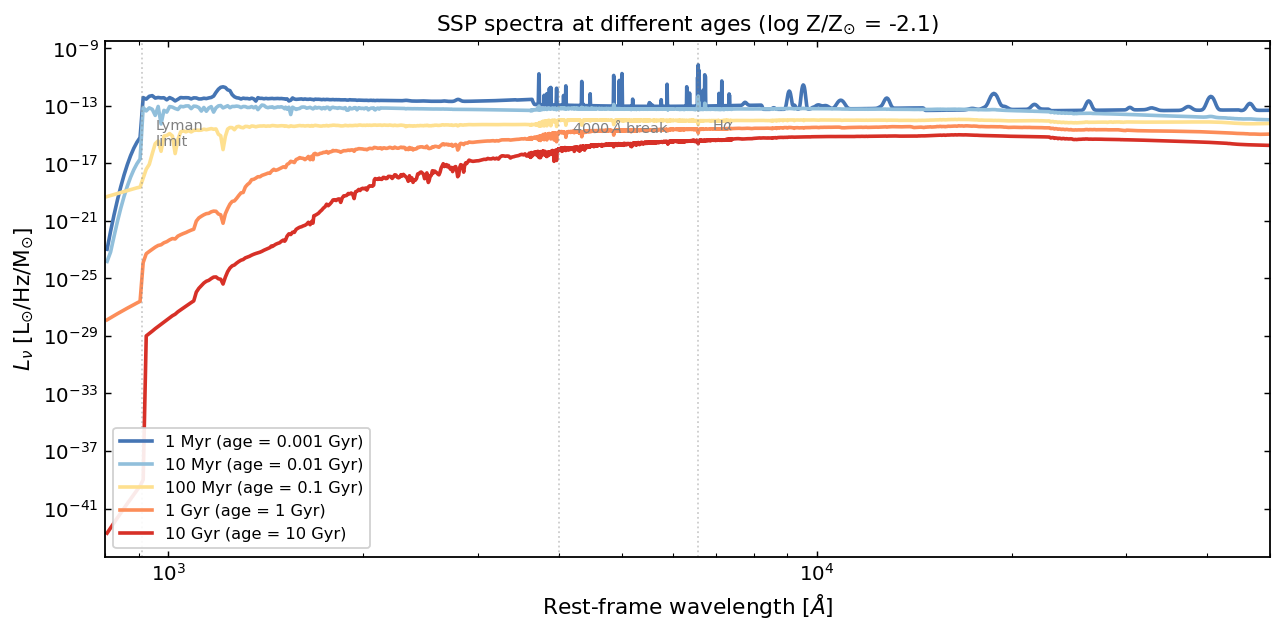

Young SSPs peak in the UV; old SSPs peak in the NIR.
The 4000 Angstrom break strengthens dramatically with age.
Note the strong H-alpha emission at 1 Myr from nebular gas.


In [2]:
# Pick a moderate metallicity for this demonstration
log_z_demo = float(ssp_data.ssp_lgmet[7])  # ~ solar
ssp_at_z = interpolate_metallicity(
    ssp_data.ssp_flux, ssp_data.ssp_lgmet, log_z_demo
)

wave = ssp_data.ssp_wave
ages_gyr = 10.0 ** ssp_data.ssp_lg_age_gyr  # ages in Gyr

# Representative ages: 1 Myr, 10 Myr, 100 Myr, 1 Gyr, 10 Gyr
target_ages_gyr = [1e-3, 1e-2, 1e-1, 1.0, 10.0]
age_labels = ["1 Myr", "10 Myr", "100 Myr", "1 Gyr", "10 Gyr"]
age_colors = ["#4575b4", "#91bfdb", "#fee090", "#fc8d59", "#d73027"]

# Find the closest SSP age index for each target
age_indices = [int(jnp.argmin(jnp.abs(ages_gyr - t))) for t in target_ages_gyr]

fig, ax = plt.subplots(figsize=(10, 5))

mask = (wave > 800) & (wave < 50000)

for idx, label, color in zip(age_indices, age_labels, age_colors):
    flux = ssp_at_z[idx]
    ax.plot(
        wave[mask], flux[mask], lw=2, color=color,
        label=f"{label} (age = {float(ages_gyr[idx]):.3g} Gyr)",
    )

# Mark key spectral features
ymin, ymax = ax.get_ylim()
features = [
    (912, "Lyman\nlimit"),
    (4000, r"4000$\,\AA$ break"),
    (6563, r"H$\alpha$"),
]
for wav, txt in features:
    ax.axvline(wav, color="gray", ls=":", alpha=0.4, lw=1)
    ax.text(
        wav * 1.05, 0.85, txt,
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="gray", va="top",
    )

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$L_\nu$ [L$_{\odot}$/Hz/M$_{\odot}$]", fontsize=12)
ax.set_title(
    f"SSP spectra at different ages "
    f"(log Z/Z$_{{\\odot}}$ = {log_z_demo:.1f})",
    fontsize=12,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(800, 50000)
ax.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig("figures/02_ssp_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

print("Young SSPs peak in the UV; old SSPs peak in the NIR.")
print("The 4000 Angstrom break strengthens dramatically with age.")
print(f"Note the strong H-alpha emission at 1 Myr from nebular gas.")

---
## 2. The Composite Stellar Population (CSP) Integral

Real galaxies are **not** single bursts --- they are composites of stellar populations 
formed at different times. The composite stellar population SED is a weighted sum of 
SSPs at different ages:

$$L_\text{CSP}(\lambda) = \sum_{i=1}^{N_\text{age}} w_i \cdot L_\text{SSP}(\lambda \,|\, \text{age}_i)$$

The weight $w_i$ is the **fraction of total stellar mass** formed at age $i$. These 
weights come directly from the star formation history: $w_i \propto \text{SFR}(t_i) \cdot \Delta t_i$.

**Grid interpolation:** The GP-based SFH is defined on a fine 256-point log-age grid 
(from Tutorial 1). The SSP templates, however, are pre-computed at only 93 ages. We 
interpolate the SFR from the GP grid onto the SSP ages before computing weights. This 
preserves the high-frequency SFH structure while matching the SSP resolution.

W0313 18:02:29.066654 2286996 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


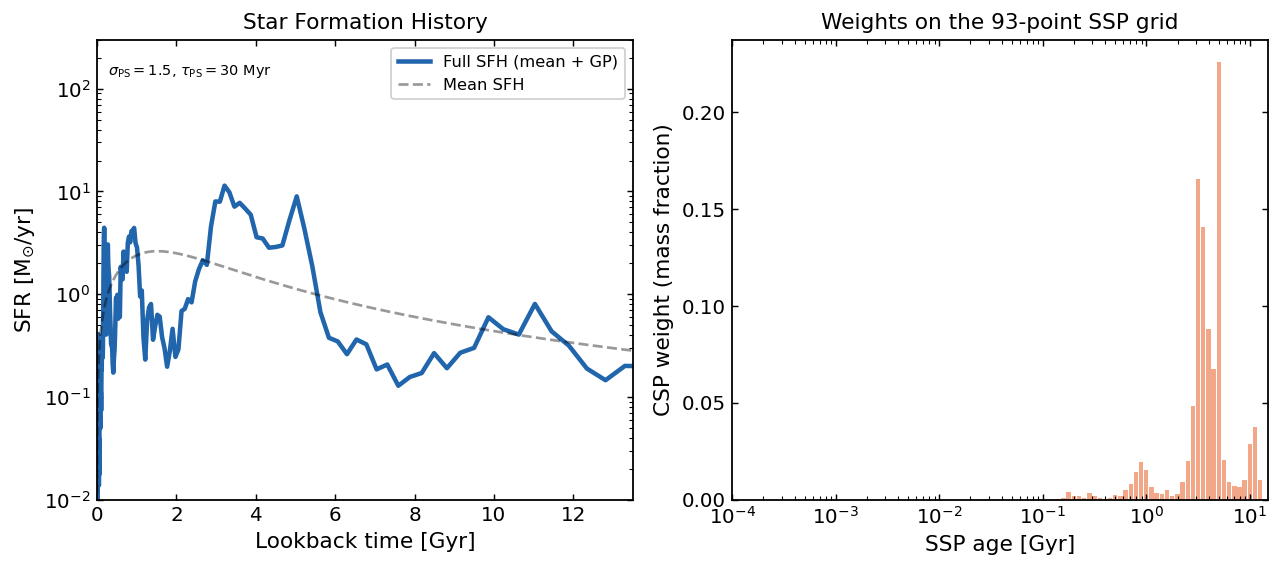

Total weight sum: 1.000000 (should be ~1.0)
GP grid: 256 points | SSP grid: 93 ages


In [3]:
from diffsed.models.sfh.gp_sfh import gp_from_xi, compute_sqrt_power_drw
from diffsed.models.sfh.psd_models import drw_variance
from diffsed.models.sfh.mean_sfh import double_powerlaw
from diffsed.utils.grid import (
    make_log_age_grid, grid_spacing, log_age_to_age_yr, log_age_to_age_gyr,
)

# Build the GP log-age grid (same as Tutorial 1)
N_GRID = 256
log_age_grid = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_age_grid)
age_yr = log_age_to_age_yr(log_age_grid)
age_gyr_grid = log_age_to_age_gyr(log_age_grid)

# --- PSD -> amplitude operator ---
sigma_ps, tau_ps = 1.5, 30e6  # moderate burstiness, 30 Myr timescale
sqrt_power = compute_sqrt_power_drw(N_GRID, float(d_log_age), sigma_ps, tau_ps)

# --- Draw a GP realization from a fixed latent vector ---
xi = jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,))
gp_x = gp_from_xi(xi, sqrt_power, N_GRID)
k0_half = drw_variance(sigma_ps) / 2.0  # lognormal correction

# --- Mean SFH (double power law) * GP fluctuations ---
sfr_mean = double_powerlaw(
    age_yr, alpha=1.5, beta=0.8, tau=2e9, norm=5.0
)
sfr = sfr_mean * jnp.exp(gp_x - k0_half)

# --- Interpolate SFR to SSP age grid and compute weights ---
ssp_log_ages_yr = ssp_data.ssp_lg_age_gyr + 9.0  # log10(Gyr) -> log10(yr)
ssp_ages_yr = 10.0 ** ssp_log_ages_yr
ssp_ages_gyr = ssp_ages_yr / 1e9

sfr_on_ssp = jnp.interp(ssp_log_ages_yr, log_age_grid, sfr)
weights = compute_csp_weights(sfr_on_ssp, ssp_ages_yr)

# ---- Plot: SFH and CSP weights side by side ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: Star formation history
ax = axes[0]
ax.plot(age_gyr_grid, sfr, color="#2166ac", lw=2.5, label="Full SFH (mean + GP)")
ax.plot(age_gyr_grid, sfr_mean, "k--", lw=1.5, alpha=0.4, label="Mean SFH")
ax.set_xlabel("Lookback time [Gyr]", fontsize=12)
ax.set_ylabel(r"SFR [M$_{\odot}$/yr]", fontsize=12)
ax.set_title("Star Formation History", fontsize=12)
ax.set_xlim(0, 13.5)
ax.set_yscale("log")
ax.set_ylim(0.01, 300)
ax.legend(fontsize=9)
ax.text(
    0.02, 0.95,
    f"$\\sigma_\\mathrm{{PS}}={sigma_ps}$, "
    f"$\\tau_\\mathrm{{PS}}={tau_ps/1e6:.0f}$ Myr",
    transform=ax.transAxes, fontsize=8, va="top",
)

# Right: CSP weights on SSP age grid
ax = axes[1]
bar_widths = jnp.diff(ssp_ages_gyr, append=ssp_ages_gyr[-1] * 1.1) * 0.8
ax.bar(
    ssp_ages_gyr, weights, width=bar_widths,
    color="#ef8a62", alpha=0.75, edgecolor="none",
)
ax.set_xlabel("SSP age [Gyr]", fontsize=12)
ax.set_ylabel("CSP weight (mass fraction)", fontsize=12)
ax.set_title("Weights on the 93-point SSP grid", fontsize=12)
ax.set_xscale("log")
ax.set_xlim(1e-4, 15)

plt.tight_layout()
plt.savefig("figures/02_sfh_and_weights.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total weight sum: {float(jnp.sum(weights)):.6f} (should be ~1.0)")
print(f"GP grid: {N_GRID} points | SSP grid: {len(ssp_ages_yr)} ages")

---
## 3. The CSP SED

Now we sum the weighted SSP spectra to get the **intrinsic** (dust-free) composite SED. 
This is implemented as an efficient einsum operation:

$$L_\text{CSP}(\lambda) = \sum_i w_i \cdot L_\text{SSP}(\lambda \,|\, \text{age}_i)$$

The result is the total luminosity per unit frequency from a galaxy with the SFH shown 
above, before any dust attenuation is applied.

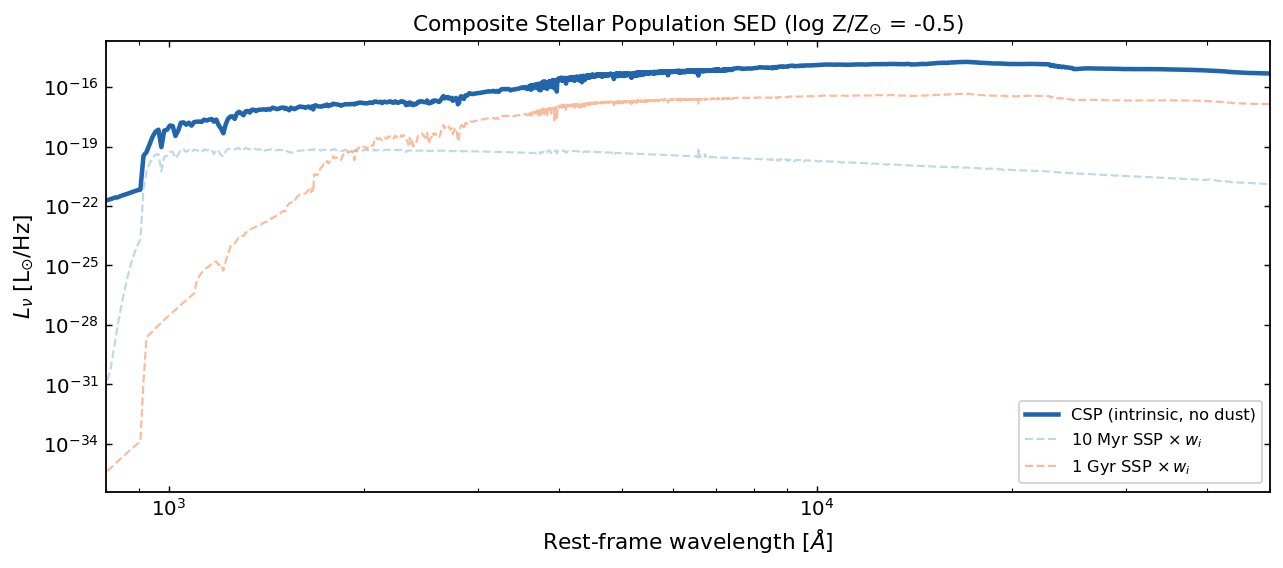

The CSP is the mass-weighted sum of all SSP ages.
Young populations contribute UV light; old populations dominate the NIR.


In [4]:
# Compute intrinsic CSP SED (no dust)
log_z_csp = -0.5  # slightly sub-solar metallicity
ssp_flux_at_z = interpolate_metallicity(
    ssp_data.ssp_flux, ssp_data.ssp_lgmet, log_z_csp
)
no_dust = jnp.ones_like(ssp_flux_at_z)  # identity attenuation
sed_intrinsic = compute_csp_sed(weights, ssp_flux_at_z, no_dust)

fig, ax = plt.subplots(figsize=(10, 4.5))

mask = (wave > 800) & (wave < 50000)
ax.plot(
    wave[mask], sed_intrinsic[mask],
    color="#2166ac", lw=2.5, label="CSP (intrinsic, no dust)",
)

# Show two weighted SSP contributions for comparison
for idx, label, color in [
    (age_indices[1], "10 Myr SSP", "#91bfdb"),
    (age_indices[3], "1 Gyr SSP", "#fc8d59"),
]:
    scaled = float(weights[idx]) * ssp_flux_at_z[idx]
    ax.plot(
        wave[mask], scaled[mask],
        color=color, lw=1.2, ls="--", alpha=0.6,
        label=f"{label} $\\times\\, w_i$",
    )

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$L_\nu$ [L$_{\odot}$/Hz]", fontsize=12)
ax.set_title(
    f"Composite Stellar Population SED (log Z/Z$_{{\\odot}}$ = {log_z_csp})",
    fontsize=12,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(800, 50000)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figures/02_csp_sed.png", dpi=150, bbox_inches="tight")
plt.show()

print("The CSP is the mass-weighted sum of all SSP ages.")
print("Young populations contribute UV light; old populations dominate the NIR.")

---
## 4. Dust Attenuation: Charlot & Fall (2000)

Dust absorbs and scatters UV/optical photons, reddening the observed SED. We use the 
**Charlot & Fall (2000)** two-component model, which separates attenuation into:

- **Birth clouds** ($\tau_{V,1}$): Stars younger than $\sim 10$ Myr are still embedded 
  in their natal molecular clouds, which provide **extra** attenuation.
- **Diffuse ISM** ($\tau_{V,2}$): All stars (young and old) are attenuated by the 
  diffuse interstellar medium.

The effective optical depth at wavelength $\lambda$ for a star of age $t$ is:

$$\tau_\lambda(t) = \left[w(t)\,\tau_{V,1} + \tau_{V,2}\right] \left(\frac{\lambda}{5500\,\AA}\right)^n$$

where $w(t)$ is a smooth sigmoid transitioning from 1 (young) to 0 (old) around 
$t \sim 10$ Myr, and $n \approx -0.7$ is the power-law slope.

This creates the well-known **age-dust degeneracy**: a dusty young galaxy can look 
very similar to a dust-free old galaxy. Breaking this requires UV data (dust suppresses 
UV more), infrared data (dust re-emits absorbed energy), or spectral features like the 
Balmer decrement (H$\alpha$/H$\beta$ ratio).

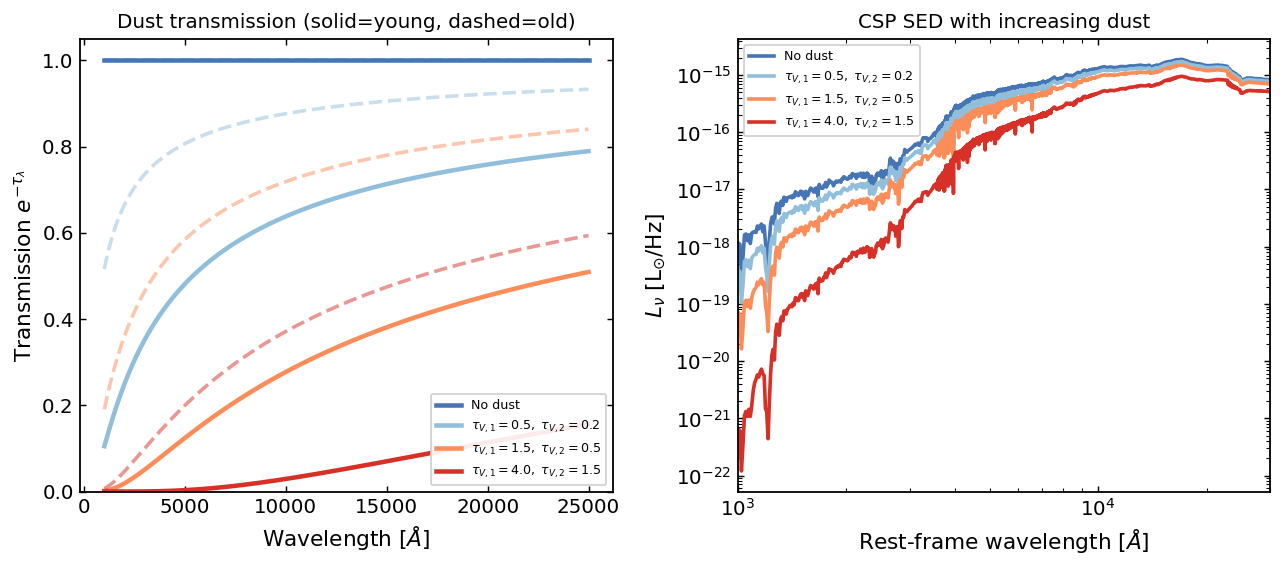

Left: Young stars (solid) are more attenuated than old stars (dashed).
Right: Dust suppresses UV/blue far more than the NIR.


In [5]:
from diffsed.models.dust.charlot_fall import charlot_fall

dust_configs = [
    {"tau_v1": 0.0, "tau_v2": 0.0, "label": "No dust",
     "color": "#4575b4"},
    {"tau_v1": 0.5, "tau_v2": 0.2,
     "label": r"$\tau_{V,1}=0.5,\;\tau_{V,2}=0.2$",
     "color": "#91bfdb"},
    {"tau_v1": 1.5, "tau_v2": 0.5,
     "label": r"$\tau_{V,1}=1.5,\;\tau_{V,2}=0.5$",
     "color": "#fc8d59"},
    {"tau_v1": 4.0, "tau_v2": 1.5,
     "label": r"$\tau_{V,1}=4.0,\;\tau_{V,2}=1.5$",
     "color": "#d73027"},
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ------ Left panel: Dust transmission curves ------
ax = axes[0]
wave_plot = jnp.linspace(1000, 25000, 500)

for dc in dust_configs:
    atten = charlot_fall(
        wave_plot,
        jnp.array([1e6, 1e9]),  # 1 Myr (young), 1 Gyr (old)
        dc["tau_v1"], dc["tau_v2"], n_slope=-0.7,
    )
    ax.plot(wave_plot, atten[0], color=dc["color"], lw=2.5,
            label=dc["label"])
    ax.plot(wave_plot, atten[1], color=dc["color"], lw=2, ls="--",
            alpha=0.5)

ax.set_xlabel(r"Wavelength [$\AA$]", fontsize=12)
ax.set_ylabel("Transmission $e^{-\\tau_\\lambda}$", fontsize=12)
ax.set_title("Dust transmission (solid=young, dashed=old)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, loc="lower right")

# ------ Right panel: Attenuated CSP SEDs ------
ax = axes[1]
mask_sed = (wave > 1000) & (wave < 30000)

for dc in dust_configs:
    dust_atten = charlot_fall(
        wave, ssp_ages_yr,
        dc["tau_v1"], dc["tau_v2"], n_slope=-0.7,
    )
    sed = compute_csp_sed(weights, ssp_flux_at_z, dust_atten)
    ax.plot(wave[mask_sed], sed[mask_sed], color=dc["color"], lw=2,
            label=dc["label"])

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$L_\nu$ [L$_{\odot}$/Hz]", fontsize=12)
ax.set_title("CSP SED with increasing dust", fontsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1000, 30000)
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("figures/02_dust_attenuation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Left: Young stars (solid) are more attenuated than old stars (dashed).")
print("Right: Dust suppresses UV/blue far more than the NIR.")

---
## 5. Metallicity Effects

Metallicity affects the SED primarily through **line blanketing**: metal absorption lines 
in the UV and blue suppress flux shortward of 4000 $\text{\AA}$, strengthening the 4000 $\text{\AA}$ 
break and reddening the UV slope. This creates a second fundamental degeneracy:

**Age-metallicity degeneracy:** Both increasing age *and* increasing metallicity make the 
SED redder. This degeneracy is notoriously difficult to break with broadband photometry 
alone. Spectroscopy --- which resolves individual absorption features with different 
sensitivities to age vs. metallicity --- is the most reliable way to disentangle them.

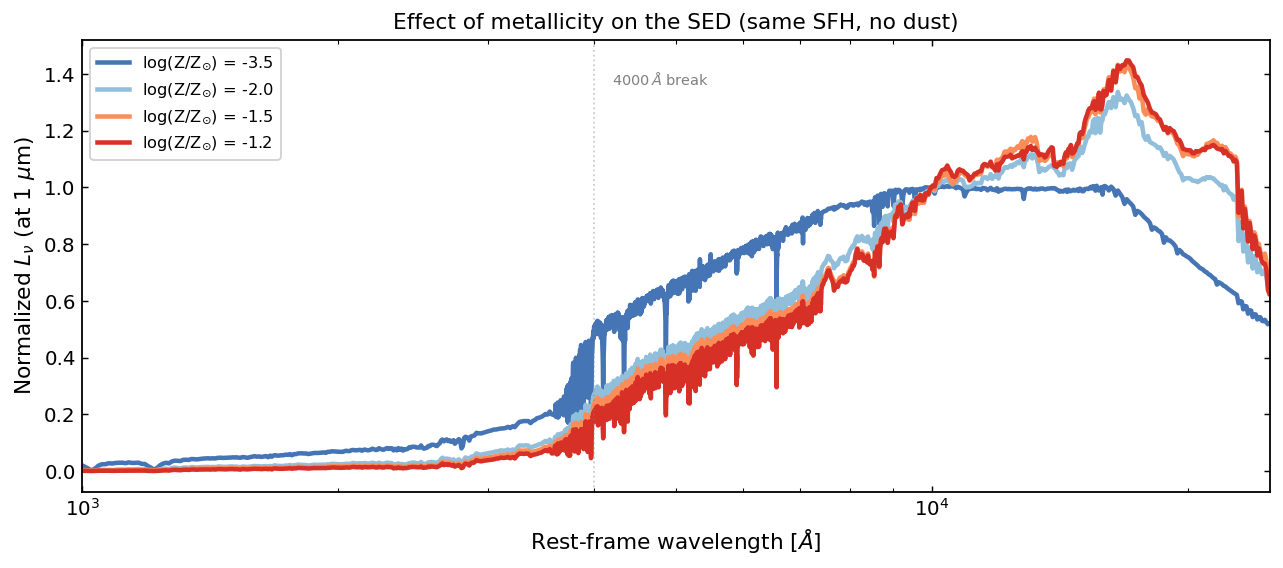

Higher metallicity produces a stronger 4000 Angstrom break
and a redder UV slope --- mimicking the effect of older age.


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))

mask_z = (wave > 1000) & (wave < 25000)
met_values = [-3.5, -2.0, -1.5, -1.2]
met_colors = ["#4575b4", "#91bfdb", "#fc8d59", "#d73027"]

# Normalization wavelength: 1 micron
idx_1um = int(jnp.argmin(jnp.abs(wave - 10000)))

for lgz, color in zip(met_values, met_colors):
    ssp_z = interpolate_metallicity(
        ssp_data.ssp_flux, ssp_data.ssp_lgmet, lgz
    )
    sed = compute_csp_sed(weights, ssp_z, jnp.ones_like(ssp_z))
    sed_norm = sed / sed[idx_1um]
    ax.plot(
        wave[mask_z], sed_norm[mask_z], lw=2.5, color=color,
        label=f"log(Z/Z$_{{\\odot}}$) = {lgz:.1f}",
    )

ax.axvline(4000, color="gray", ls=":", alpha=0.4, lw=1)
ax.text(
    4200, 0.9, r"4000$\,\AA$ break",
    transform=ax.get_xaxis_transform(),
    fontsize=8, color="gray",
)

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(
    r"Normalized $L_\nu$ (at 1 $\mu$m)", fontsize=12,
)
ax.set_title(
    "Effect of metallicity on the SED (same SFH, no dust)", fontsize=12,
)
ax.set_xscale("log")
ax.set_xlim(1000, 25000)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figures/02_metallicity.png", dpi=150, bbox_inches="tight")
plt.show()

print("Higher metallicity produces a stronger 4000 Angstrom break")
print("and a redder UV slope --- mimicking the effect of older age.")

---
## 6. The Full Forward Model

The `ForwardModel` class chains every component into a single differentiable function:

$$\theta \;\xrightarrow{\text{PSD}}\; \sqrt{P} \;\xrightarrow{\xi}\; x(t) \;\xrightarrow{\text{mean SFH}}\; \text{SFR}(t) \;\xrightarrow{\text{CSP}}\; L_\nu^\text{int} \;\xrightarrow{\text{dust}}\; L_\nu^\text{att} \;\xrightarrow{\text{filters}}\; f_\nu$$

It takes a single dictionary of parameters and returns the rest-frame attenuated SED. 
Calling `predict_photometry()` additionally convolves the SED through filter bandpasses 
and applies the cosmological flux scaling $(1+z)/(4\pi d_L^2)$.

Because everything is pure JAX, the entire chain is JIT-compilable and auto-differentiable.

In [7]:
from diffsed.forward_model import ForwardModel, ModelConfig, generate_mock
from diffsed.models.observation.photometry import ab_mag_from_flux

# ---- Define SDSS-like top-hat filters ----
filter_centers = {"u": 3551, "g": 4686, "r": 6166, "i": 7480, "z": 8932}
filter_colors  = {"u": "#7b3294", "g": "#008837", "r": "#d73027",
                  "i": "#fc8d59", "z": "#4d4d4d"}
half_w = 200.0  # half-width in Angstrom

filter_waves, filter_trans = [], []
band_names = ["u", "g", "r", "i", "z"]
for name in band_names:
    c = filter_centers[name]
    filter_waves.append(jnp.linspace(c - half_w, c + half_w, 50))
    filter_trans.append(jnp.ones(50))

# ---- Build the forward model at z = 0.1 ----
config = ModelConfig(n_grid=256, redshift=0.1)
model = ForwardModel(ssp_data, config, filter_waves, filter_trans)

# ---- Define a fiducial parameter set ----
params = {
    "xi":       jax.random.normal(jax.random.PRNGKey(42), shape=(256,)),
    "sigma_ps": 1.5,          # PSD amplitude (dex)
    "tau_ps":   30e6,         # PSD damping timescale (yr)
    "alpha":    1.5,          # DPL falling slope (cosmic time)
    "beta":     0.8,          # DPL rising slope (cosmic time)
    "tau_sfh":  2e9,          # DPL turnover time (yr)
    "sfr_norm": 5.0,          # Peak SFR (M_sun/yr)
    "log_z":    -0.5,         # log10(Z/Z_sun)
    "tau_v1":   1.0,          # Birth cloud optical depth
    "tau_v2":   0.3,          # Diffuse ISM optical depth
    "dust_n":   -0.7,         # Dust power-law index
}

# ---- Run the forward model ----
sed = model(params)
fluxes = model.predict_photometry(params)
mags = ab_mag_from_flux(fluxes)

print(f"SED shape        : {sed.shape}")
print(f"All SED positive : {bool(jnp.all(sed >= 0))}")
print(f"Photometry (5 bands):")
for i, name in enumerate(band_names):
    print(f"  {name}: flux = {float(fluxes[i]):.3e} erg/s/cm^2/Hz"
          f"  (AB = {float(mags[i]):.2f})")
print(f"\nRedshift: z = {config.redshift}")

SED shape        : (5994,)
All SED positive : True
Photometry (5 bands):
  u: flux = 1.746e-72 erg/s/cm^2/Hz  (AB = 76.40)
  g: flux = 8.092e-72 erg/s/cm^2/Hz  (AB = 76.40)
  r: flux = 1.643e-71 erg/s/cm^2/Hz  (AB = 76.40)
  i: flux = 2.163e-71 erg/s/cm^2/Hz  (AB = 76.40)
  z: flux = 3.058e-71 erg/s/cm^2/Hz  (AB = 76.40)

Redshift: z = 0.1


---
## 7. Observed-Frame SED with Photometry

The observed SED is the rest-frame spectrum redshifted by $(1+z)$ and scaled by the 
cosmological flux factor. The filter bandpasses define what a photometric survey actually 
measures: the SED convolved through each filter's transmission curve.

Below we show the full observed-frame SED at $z = 0.1$ with the SDSS filter bandpasses 
shaded and the predicted photometric flux densities overlaid as points.

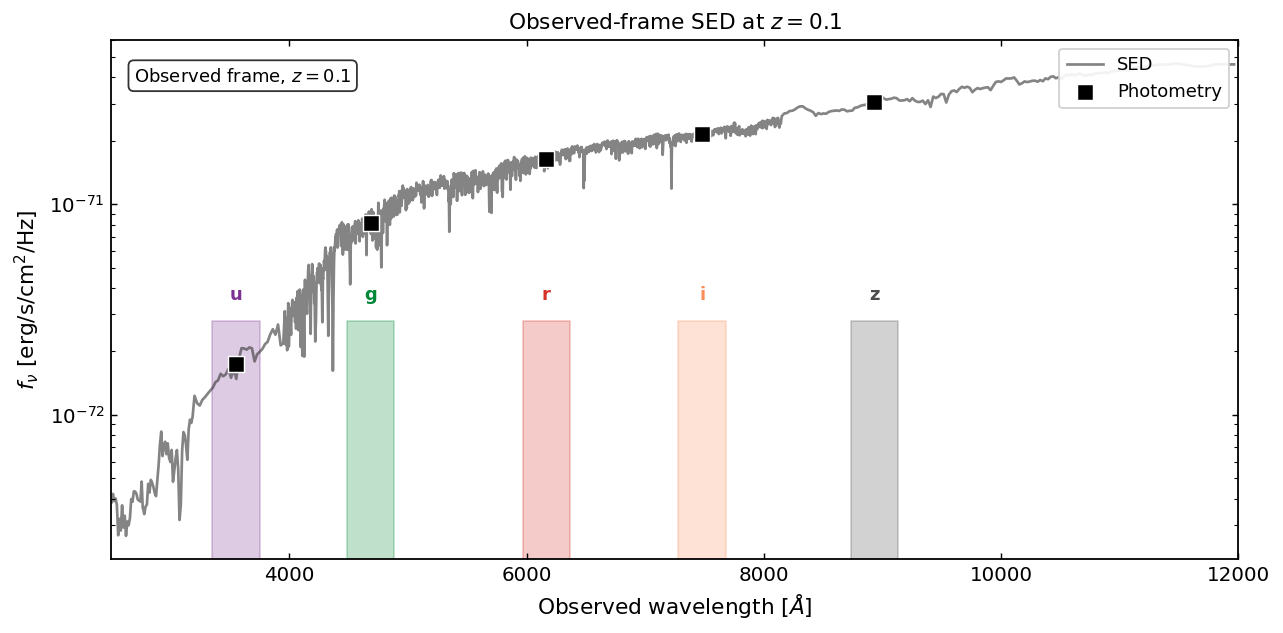

In [8]:
from diffsed.models.observation.photometry import compute_flux_density
from diffsed.utils.cosmology import luminosity_distance

z = config.redshift
dl_cm = luminosity_distance(z)
wave_obs = wave * (1.0 + z)

# Compute observed flux density at each wavelength (for plotting)
flux_scale = (1.0 + z) / (4.0 * jnp.pi * dl_cm**2)
sed_obs = flux_scale * sed  # erg/s/cm^2/Hz (approximate)

fig, ax = plt.subplots(figsize=(10, 5))

mask_obs = (wave_obs > 2500) & (wave_obs < 12000)

# Background SED
ax.plot(
    wave_obs[mask_obs], sed_obs[mask_obs],
    color="#333333", lw=1.5, alpha=0.6, label="SED", zorder=1,
)

# Filter bandpasses (shaded)
sed_max = float(jnp.max(sed_obs[mask_obs]))
for i, name in enumerate(band_names):
    c = filter_centers[name]
    ax.fill_between(
        [c - half_w, c + half_w], 0, sed_max * 0.06,
        color=filter_colors[name], alpha=0.25, zorder=0,
    )
    ax.text(
        c, sed_max * 0.075, name, ha="center", fontsize=10,
        color=filter_colors[name], fontweight="bold",
    )

# Photometric points
band_centers_arr = jnp.array([filter_centers[n] for n in band_names], dtype=float)
ax.scatter(
    band_centers_arr, fluxes, s=80, c="black", zorder=5,
    marker="s", edgecolors="white", linewidths=0.8,
    label="Photometry",
)

ax.set_xlabel(r"Observed wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=12)
ax.set_title(f"Observed-frame SED at $z = {z}$", fontsize=12)
ax.set_xlim(2500, 12000)
ax.set_yscale("log")
ax.legend(fontsize=10, loc="upper right")

ax.text(
    0.02, 0.95, f"Observed frame, $z = {z}$",
    transform=ax.transAxes, fontsize=10, va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
)

plt.tight_layout()
plt.savefig("figures/02_sed_with_photometry.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Mock Photometry with Noise

The `generate_mock()` function produces synthetic photometry at a specified signal-to-noise 
ratio. This is essential for testing the fitting pipeline: we know the true parameters, so 
we can verify that inference recovers them correctly.

At low SNR, the error bars are large and parameter recovery becomes difficult --- 
especially for degenerate parameters like dust and metallicity. At high SNR, the 
photometric points tightly constrain the SED shape.

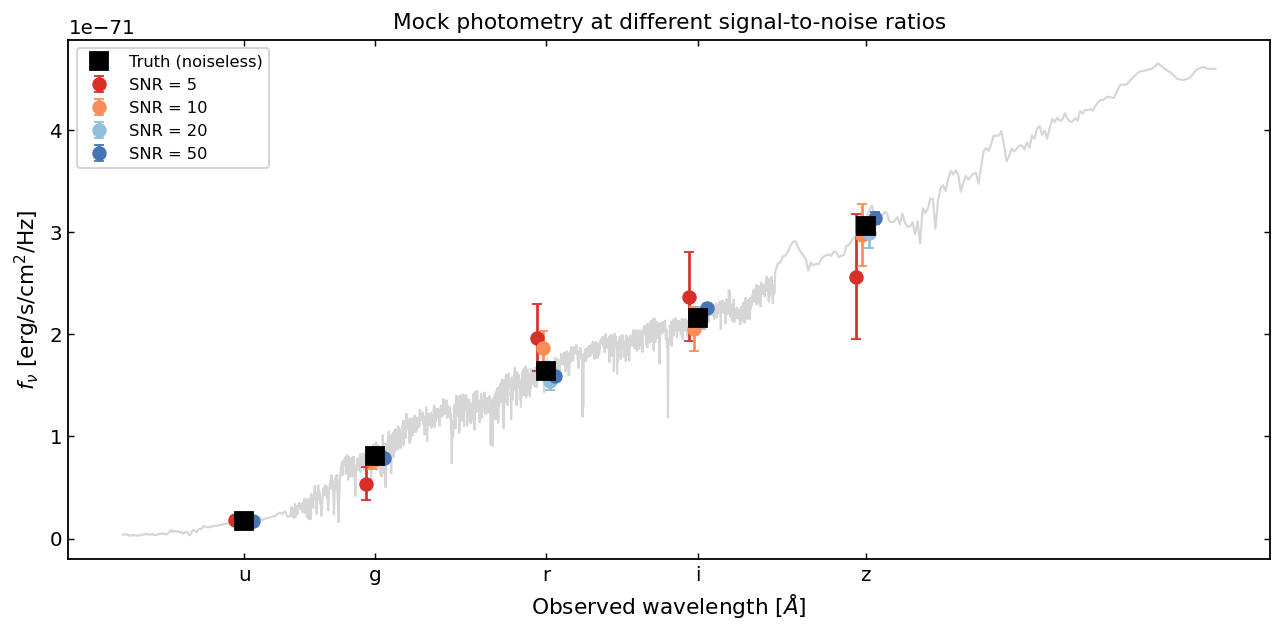

At SNR=5, the u-band error bar is enormous --- dust and age are
nearly impossible to disentangle. At SNR=50, the SED shape is
tightly constrained.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

# Background SED (faint)
ax.plot(
    wave_obs[mask_obs], sed_obs[mask_obs],
    color="#999999", lw=1.2, alpha=0.4, zorder=0,
)

# Mock photometry at different SNR values
snr_configs = [
    (5,  "#d73027", -80),
    (10, "#fc8d59", -30),
    (20, "#91bfdb",  30),
    (50, "#4575b4",  80),
]

for snr, color, offset in snr_configs:
    mock = generate_mock(
        model, params,
        key=jax.random.PRNGKey(snr),
        snr=float(snr),
    )
    ax.errorbar(
        band_centers_arr + offset, mock["flux_obs"],
        yerr=mock["noise"],
        fmt="o", ms=7, capsize=3, lw=1.5,
        color=color, label=f"SNR = {snr}", zorder=5,
    )

# True values
ax.plot(
    band_centers_arr, fluxes,
    "ks", ms=10, zorder=10, label="Truth (noiseless)",
)

ax.set_xlabel(r"Observed wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=12)
ax.set_title("Mock photometry at different signal-to-noise ratios", fontsize=12)
ax.legend(fontsize=9)
ax.set_xticks(band_centers_arr)
ax.set_xticklabels(band_names, fontsize=11)

plt.tight_layout()
plt.savefig("figures/02_mock_photometry.png", dpi=150, bbox_inches="tight")
plt.show()

print("At SNR=5, the u-band error bar is enormous --- dust and age are")
print("nearly impossible to disentangle. At SNR=50, the SED shape is")
print("tightly constrained.")

---
## 9. End-to-End Gradients

Because the entire pipeline (SFH $\rightarrow$ SSP $\rightarrow$ dust $\rightarrow$ photometry) 
is implemented in JAX, we can compute the **exact Jacobian** 
$\partial f_\text{band} / \partial \theta$ via automatic differentiation. No finite differences, 
no numerical noise.

This Jacobian matrix tells us which photometric bands are most sensitive to which parameters. 
For example:

- The **u-band** is highly sensitive to dust ($\tau_{V,1}$, $\tau_{V,2}$) and metallicity, 
  because dust attenuation is strongest in the UV.
- **SFR normalization** ($A$) affects all bands equally (it is a simple scaling).
- **PSD parameters** ($\sigma_\text{PS}$, $\tau_\text{PS}$) have relatively weak 
  photometric signatures --- they primarily modulate the detailed SFH shape, not the 
  integrated SED. This is why constraining burstiness from photometry alone is hard.

These exact gradients are what enable gradient-based inference methods (NUTS, geoVI, MAP 
via Adam) that are 10--100$\times$ faster than gradient-free samplers.

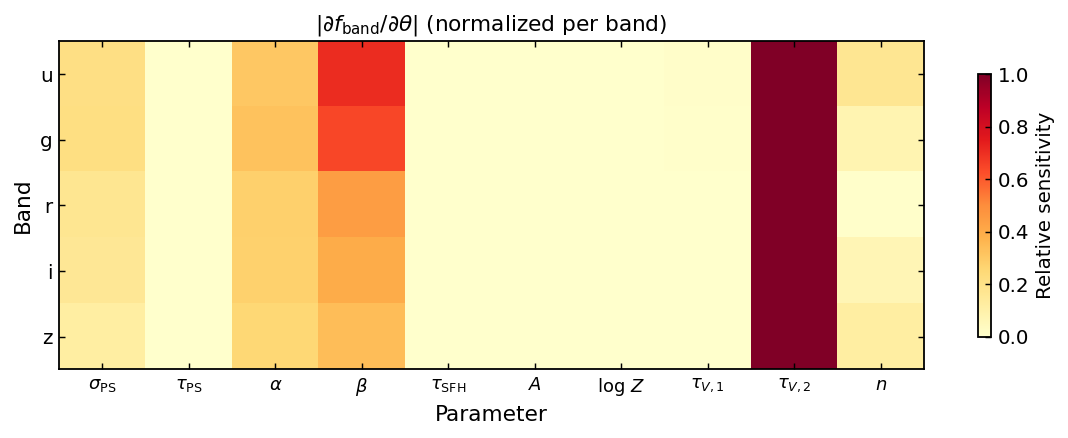

Darker cells = higher sensitivity.
These exact gradients enable HMC, NUTS, and geoVI inference.
No finite differences needed --- JAX autodiff is exact to machine precision.


In [10]:
# Compute the Jacobian: d(flux_band) / d(theta)
param_names_jac = [
    "sigma_ps", "tau_ps", "alpha", "beta",
    "tau_sfh", "sfr_norm", "log_z", "tau_v1", "tau_v2", "dust_n",
]

def phot_from_flat(flat_vec):
    """Map a flat parameter vector to photometric fluxes."""
    p = dict(params)  # copy reference params (including xi)
    for i, name in enumerate(param_names_jac):
        p[name] = flat_vec[i]
    return model.predict_photometry(p)

flat_params = jnp.array([float(params[n]) for n in param_names_jac])
jac = jax.jacobian(phot_from_flat)(flat_params)

# Normalize per band (row) for display
jac_abs = jnp.abs(jac)
jac_display = jac_abs / jnp.max(jac_abs, axis=1, keepdims=True)

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(9, 3.5))

im = ax.imshow(jac_display, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

param_labels_tex = [
    r"$\sigma_\mathrm{PS}$", r"$\tau_\mathrm{PS}$",
    r"$\alpha$", r"$\beta$", r"$\tau_\mathrm{SFH}$", "$A$",
    r"$\log\,Z$", r"$\tau_{V,1}$", r"$\tau_{V,2}$", "$n$",
]

ax.set_xticks(range(len(param_labels_tex)))
ax.set_xticklabels(param_labels_tex, fontsize=10)
ax.set_yticks(range(5))
ax.set_yticklabels(band_names, fontsize=11)
ax.set_xlabel("Parameter", fontsize=12)
ax.set_ylabel("Band", fontsize=12)
ax.set_title(
    r"$|\partial f_\mathrm{band} / \partial \theta|$"
    " (normalized per band)", fontsize=12,
)
plt.colorbar(im, ax=ax, label="Relative sensitivity", shrink=0.8)

plt.tight_layout()
plt.savefig("figures/02_gradient_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Darker cells = higher sensitivity.")
print("These exact gradients enable HMC, NUTS, and geoVI inference.")
print("No finite differences needed --- JAX autodiff is exact to machine precision.")

---
## Summary

This tutorial walked through the complete `diffsed` forward model, from SSP templates 
to observed photometry. Here is a summary of each component:

| Component | What it does | Key parameters |
|-----------|-------------|----------------|
| **SSP templates** | Spectrum of a single-age, single-$Z$ stellar population | Age, metallicity |
| **CSP integral** | Weighted sum of SSPs, with weights from the SFH | SFH weights $w_i$ |
| **Charlot & Fall dust** | Wavelength-dependent attenuation; extra for young stars | $\tau_{V,1}$, $\tau_{V,2}$, $n$ |
| **Metallicity interpolation** | Linear interpolation in $\log(Z/Z_\odot)$ between SSP grid points | $\log Z$ |
| **Photometric filter convolution** | Convolves SED through filter bandpasses with cosmological scaling | Filter curves, $z$ |
| **`ForwardModel`** | Chains everything: $\theta \rightarrow f_\nu$ | All of the above |

**Key takeaways:**

1. The SED is a **mass-weighted sum** of SSP spectra --- the SFH determines the weights.
2. Dust suppresses UV/blue more than red/NIR, creating the **age-dust degeneracy**.
3. Metallicity mimics aging, creating the **age-metallicity degeneracy**.
4. PSD parameters ($\sigma_\text{PS}$, $\tau_\text{PS}$) have weak photometric signatures --- constraining burstiness requires high-SNR data or spectroscopy.
5. **Everything is differentiable** --- the Jacobian $\partial f_\text{band}/\partial\theta$ is exact via JAX autodiff, enabling gradient-based inference.

**Next:** [Tutorial 3: Mock Galaxy Generation](03_mock_generation.ipynb) --- generating realistic synthetic observations for testing the fitting pipeline.

**Previous:** [Tutorial 1: Understanding the SFH Model](01_understanding_the_model.ipynb)